### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Load & Inspect C6

In [2]:
df = pd.read_csv('clusters/cluster_6.csv')
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Bankrupt?'].value_counts())
print(f"\nBankruptcy rate: {df['Bankrupt?'].mean()*100:.1f}%")

# With only 7 rows, print the whole thing
print("\nFull dataset:")
display(df[['Index', 'Bankrupt?',
            'ROA(A) before interest and % after tax',
            'Working Capital to Total Assets',
            'Current Liability to Current Assets',
            'Retained Earnings to Total Assets',
            'Current Liability to Assets',
            'Debt ratio %']].round(4))

Shape: (7, 98)

Class distribution:
Bankrupt?
1    5
0    2
Name: count, dtype: int64

Bankruptcy rate: 71.4%

Full dataset:


,Index,Bankrupt?,ROA(A) before interest and % after tax,Working Capital to Total Assets,Current Liability to Current Assets,Retained Earnings to Total Assets,Current Liability to Assets,Debt ratio %
0,208,1,0.2110,0.7232,0.0594,0.7776,0.1657,0.5254
1,1978,1,0.0572,0.6924,0.0653,0.8420,0.2523,0.3214
2,2468,1,0.2236,0.6431,0.1939,0.8440,0.1602,0.3385
3,2937,0,0.2834,0.0000,0.3058,0.5924,1.0000,1.0000
4,3738,1,0.4322,0.7201,0.0544,0.9071,0.3077,0.3054
5,4060,0,0.4537,0.4752,1.0000,0.8631,0.3239,0.3128
6,5052,1,0.0902,0.4942,0.2966,0.8040,0.3431,0.3319


### Custom Accuracy Metric

In [3]:
def custom_accuracy(y_true, y_pred):
    """
    Project metric: TT / (TF + TT)
    = how many actual bankruptcies we correctly caught
    Standard recall for class=1.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    TT = int(((y_true == 1) & (y_pred == 1)).sum())
    TF = int(((y_true == 1) & (y_pred == 0)).sum())
    if TT + TF == 0:
        return 0.0
    return TT / (TT + TF)

def print_breakdown(y_true, y_pred, label=""):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    TT = int(((y_true==1) & (y_pred==1)).sum())
    TF = int(((y_true==1) & (y_pred==0)).sum())
    FT = int(((y_true==0) & (y_pred==1)).sum())
    FF = int(((y_true==0) & (y_pred==0)).sum())
    acc = custom_accuracy(y_true, y_pred)
    print(f"{'='*40}")
    if label: print(f"  {label}")
    print(f"  TT (bankrupt → bankrupt): {TT}")
    print(f"  TF (bankrupt → healthy):  {TF}")
    print(f"  FT (healthy  → bankrupt): {FT}")
    print(f"  FF (healthy  → healthy):  {FF}")
    print(f"  Custom Accuracy (TT/(TF+TT)): {acc:.4f}")
    print(f"{'='*40}")

print("Custom metric defined.")

Custom metric defined.


### The  Feature Selection for C6.

Features selected: 5
Dataset: 7 rows × 5 features



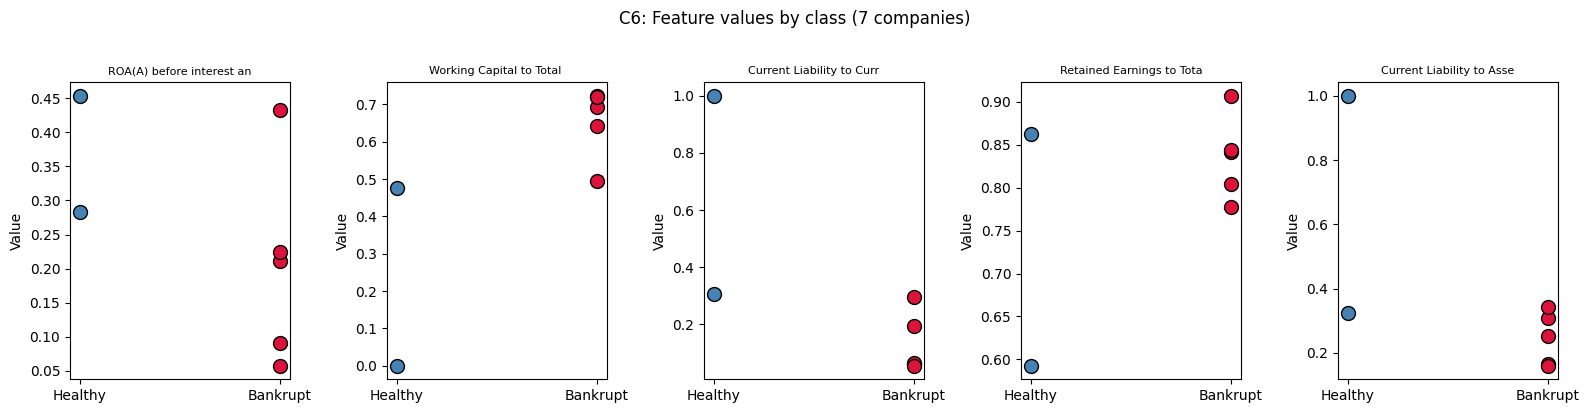

In [4]:
X_all = df.drop(columns=['Index', 'Bankrupt?', 'Cluster'])
y     = df['Bankrupt?'].copy()
# Cross-referencing Phase 1 EDA top discriminative features + within-C6 analysis

SELECTED_FEATURES = [
    'ROA(A) before interest and % after tax',       # profitability
    'Working Capital to Total Assets',               # liquidity buffer
    'Current Liability to Current Assets',           # short-term pressure
    'Retained Earnings to Total Assets',             # long-term profitability
    'Current Liability to Assets',                   # leverage
]
X = X_all[SELECTED_FEATURES].copy()
print(f"Features selected: {len(SELECTED_FEATURES)}")
print(f"Dataset: {X.shape[0]} rows × {X.shape[1]} features\n")

# Visual check — see actual values per class
fig, axes = plt.subplots(1, len(SELECTED_FEATURES), figsize=(16, 4))
for ax, feat in zip(axes, SELECTED_FEATURES):
    for label, color, name in [(0,'steelblue','Healthy'), (1,'crimson','Bankrupt')]:
        vals = X.loc[y == label, feat].values
        ax.scatter([name]*len(vals), vals, color=color, s=100, edgecolor='black')
    ax.set_title(feat[:25], fontsize=8)
    ax.set_ylabel('Value')
plt.suptitle('C6: Feature values by class (7 companies)', y=1.02)
plt.tight_layout()
plt.show()

### Define Base Models & Stacking Classifier

In [5]:
# LOO is the only valid CV strategy here
loo = LeaveOneOut()

base_estimators = [
    ('lr',  LogisticRegression(C=0.1, max_iter=2000, random_state=RANDOM_STATE)),
    ('dt',  DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)),   # decision stump
    ('knn', KNeighborsClassifier(n_neighbors=1)),
]

meta_model = LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
def build_pipeline():
    stacking = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_model,
        cv=2,                      # StratifiedKFold(2) — safe for 7 rows
        stack_method='predict_proba',
        passthrough=False,
        n_jobs=1
    )
    return Pipeline([
        ('scaler',   StandardScaler()),
        ('stacking', stacking)
    ])

print("build_pipeline uses cv=2 (StratifiedKFold). Safe for 7 rows.")
print("Base models: Logistic Regression (C=0.1), Decision Stump (depth=1), KNN (k=1)")
print("Meta model:  Logistic Regression (C=1.0)")
print("CV strategy: Leave-One-Out (only valid option with 7 rows)")

build_pipeline uses cv=2 (StratifiedKFold). Safe for 7 rows.
Base models: Logistic Regression (C=0.1), Decision Stump (depth=1), KNN (k=1)
Meta model:  Logistic Regression (C=1.0)
CV strategy: Leave-One-Out (only valid option with 7 rows)


### LOO Evaluation (honest estimate)

In [6]:
from sklearn.base import clone

loo_preds = np.zeros(len(y), dtype=int)

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr        = y.iloc[train_idx]

    # Scale per fold
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    # Fit each base model independently and collect votes
    votes = []
    for name, est in base_estimators:
        m = clone(est)
        m.fit(X_tr_s, y_tr)
        votes.append(int(m.predict(X_te_s)[0]))

    # Majority vote (2 out of 3)
    loo_preds[test_idx] = 1 if sum(votes) >= 2 else 0

print("LOO Cross-Validation Results")
print("(Majority vote across 3 base models — avoids nested single-class fold issue)\n")
print_breakdown(y, loo_preds, label="LOO Evaluation")

print("\nPer-company prediction:")
result_df = df[['Index', 'Bankrupt?']].copy()
result_df['LOO_Prediction'] = loo_preds
result_df['Correct'] = (result_df['Bankrupt?'] == result_df['LOO_Prediction'])
print(result_df.to_string(index=False))

LOO Cross-Validation Results
(Majority vote across 3 base models — avoids nested single-class fold issue)

  LOO Evaluation
  TT (bankrupt → bankrupt): 5
  TF (bankrupt → healthy):  0
  FT (healthy  → bankrupt): 2
  FF (healthy  → healthy):  0
  Custom Accuracy (TT/(TF+TT)): 1.0000

Per-company prediction:
 Index  Bankrupt?  LOO_Prediction  Correct
   208          1               1     True
  1978          1               1     True
  2468          1               1     True
  2937          0               1    False
  3738          1               1     True
  4060          0               1    False
  5052          1               1     True


### Fit Final Model on All 7 Rows

In [7]:
# Refit on all 7 rows — this is the model that will be saved and used at test time
final_pipeline = build_pipeline()
final_pipeline.fit(X, y)

# Train predictions (in-sample)
train_preds = final_pipeline.predict(X)

print("Final model fitted on all 7 training rows.\n")
print_breakdown(y, train_preds, label="Train Accuracy (in-sample)")

print(f"\nSparsity check: {train_preds.sum()} / {len(train_preds)} predicted bankrupt",
      f"({train_preds.mean()*100:.1f}%)")

Final model fitted on all 7 training rows.

  Train Accuracy (in-sample)
  TT (bankrupt → bankrupt): 5
  TF (bankrupt → healthy):  0
  FT (healthy  → bankrupt): 2
  FF (healthy  → healthy):  0
  Custom Accuracy (TT/(TF+TT)): 1.0000

Sparsity check: 7 / 7 predicted bankrupt (100.0%)


### Save to Joblib

In [10]:
import joblib
# Absolute save path
save_path = r"C:\Users\Khush\Documents\559 semester -2\559-project\Stacked_Models\c6_stacking_model.joblib"
c6_model = {
    'cluster_id': 6,
    'feature_cols': SELECTED_FEATURES,
    'model': final_pipeline,
    'n_train': len(y),
    'n_bankrupt': int(y.sum()),
    'note': 'LOO stacking — LR + DTree(d=1) + KNN(k=1) → LR meta'
}
joblib.dump(c6_model, save_path)
# Reload test
loaded = joblib.load(save_path)
test_preds = loaded['model'].predict(X[loaded['feature_cols']])
assert list(test_preds) == list(train_preds), "Reload mismatch!"
print("Reload test passed — predictions match.")
print("\nSaved model info:")
for k, v in c6_model.items():
    if k != 'model':
        print(f"{k}: {v}")

Reload test passed — predictions match.

Saved model info:
cluster_id: 6
feature_cols: ['ROA(A) before interest and % after tax', 'Working Capital to Total Assets', 'Current Liability to Current Assets', 'Retained Earnings to Total Assets', 'Current Liability to Assets']
n_train: 7
n_bankrupt: 5
note: LOO stacking — LR + DTree(d=1) + KNN(k=1) → LR meta


In [11]:
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'script', 'stacking-C6-model.ipynb'])
print("Converted: stacking-C6-model.py")

Converted: stacking-C6-model.py
